<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%94%D0%97_Ultra_Pro_%D0%92%D0%B0%D1%80%D0%B8%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D0%B0%D0%B2%D1%82%D0%BE%D0%BA%D0%BE%D0%B4%D0%B8%D1%80%D0%BE%D0%B2%D1%89%D0%B8%D0%BA%D0%B8_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Давайте немного отвлечемся от тяжелых будней будущего нейронщика и вспомним, что в мире есть маленькие радости - а именно мультяшки.

В этой работе:
- скачайте датасет от Гугла с мультяшными персонажами. Ссылка: https://storage.yandexcloud.net/aiueducation/Content/advanced/l1/cartoonset10k.zip
- обучите VAE на данном датасете
- посмотрите качество воспроизведения мультяшек
- нагенерите любое колличество мультяшек на свой вкус
- оцените работу декодера

In [1]:
# Импортируем TensorFlow
import tensorflow as tf
# Импортируем Keras
import keras
# Подключим Numpy
import numpy as np

# Подключим библиотеку отображения графиков
import matplotlib.pyplot as plt

# Подключим датасет рукописных цифр MNIST
from tensorflow.keras.datasets import mnist

# Импортируем Keras
from tensorflow import keras

# Подключим все необходимые слои Keras
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input, Lambda, LeakyReLU
from tensorflow.keras.layers import BatchNormalization, Dropout, concatenate, Conv2D, Conv2DTranspose

# Подключим модуль вычислений на Keras
import keras.backend as K

# Подключим модуль работы с операционной системой
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # От tensorflow будет получать только ошибки

In [2]:
!wget https://storage.yandexcloud.net/aiueducation/Content/advanced/l1/cartoonset10k.zip

--2025-10-15 15:19:51--  https://storage.yandexcloud.net/aiueducation/Content/advanced/l1/cartoonset10k.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 478562192 (456M) [application/x-zip-compressed]
Saving to: ‘cartoonset10k.zip’

cartoonset10k.zip   100%[===================>] 456.39M  30.6MB/s    in 15s     

2025-10-15 15:20:07 (30.0 MB/s) - ‘cartoonset10k.zip’ saved [478562192/478562192]



In [3]:
!unzip  cartoonset10k.zip
!mkdir cartoonset
!mv *.csv cartoonset/
!mv *.png cartoonset/

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: cs11126579198544594328.png  
  inflating: cs11126790993554612008.csv  
  inflating: cs11126790993554612008.png  
  inflating: cs11126969729999946215.csv  
  inflating: cs11126969729999946215.png  
  inflating: cs11127058660950110377.csv  
  inflating: cs11127058660950110377.png  
  inflating: cs11127100646503161791.csv  
  inflating: cs11127100646503161791.png  
  inflating: cs1112753606227713986.csv  
  inflating: cs1112753606227713986.png  
  inflating: cs11127672965605267927.csv  
  inflating: cs11127672965605267927.png  
  inflating: cs11127912451037839778.csv  
  inflating: cs11127912451037839778.png  
  inflating: cs11127973229079800388.csv  
  inflating: cs11127973229079800388.png  
  inflating: cs11128029188383210351.csv  
  inflating: cs11128029188383210351.png  
  inflating: cs11128263507216863964.csv  
  inflating: cs11128263507216863964.png  
  inflating: cs11128307201003681234.csv  
  inflatin

всего картинок: 10000
размер: 500x500


array([['eye_lashes', 0, 2],
       ['eye_lid', 0, 2],
       ['chin_length', 0, 3],
       ['eyebrow_weight', 0, 2],
       ['eyebrow_shape', 4, 14],
       ['eyebrow_thickness', 1, 4],
       ['face_shape', 0, 7],
       ['facial_hair', 0, 15],
       ['hair', 3, 111],
       ['eye_color', 0, 5],
       ['face_color', 3, 11],
       ['hair_color', 4, 10],
       ['glasses', 11, 12],
       ['glasses_color', 0, 7],
       ['eye_slant', 2, 3],
       ['eyebrow_width', 2, 3],
       ['eye_eyebrow_distance', 0, 3]], dtype=object)

array([['eye_lashes', 0, 2],
       ['eye_lid', 0, 2],
       ['chin_length', 0, 3],
       ['eyebrow_weight', 0, 2],
       ['eyebrow_shape', 10, 14],
       ['eyebrow_thickness', 1, 4],
       ['face_shape', 6, 7],
       ['facial_hair', 14, 15],
       ['hair', 2, 111],
       ['eye_color', 1, 5],
       ['face_color', 6, 11],
       ['hair_color', 4, 10],
       ['glasses', 7, 12],
       ['glasses_color', 3, 7],
       ['eye_slant', 0, 3],
       ['eyebrow_width', 0, 3],
       ['eye_eyebrow_distance', 2, 3]], dtype=object)

array([['eye_lashes', 1, 2],
       ['eye_lid', 1, 2],
       ['chin_length', 1, 3],
       ['eyebrow_weight', 1, 2],
       ['eyebrow_shape', 2, 14],
       ['eyebrow_thickness', 0, 4],
       ['face_shape', 5, 7],
       ['facial_hair', 13, 15],
       ['hair', 68, 111],
       ['eye_color', 3, 5],
       ['face_color', 0, 11],
       ['hair_color', 8, 10],
       ['glasses', 1, 12],
       ['glasses_color', 3, 7],
       ['eye_slant', 1, 3],
       ['eyebrow_width', 0, 3],
       ['eye_eyebrow_distance', 2, 3]], dtype=object)

array([['eye_lashes', 0, 2],
       ['eye_lid', 1, 2],
       ['chin_length', 2, 3],
       ['eyebrow_weight', 0, 2],
       ['eyebrow_shape', 9, 14],
       ['eyebrow_thickness', 2, 4],
       ['face_shape', 1, 7],
       ['facial_hair', 0, 15],
       ['hair', 25, 111],
       ['eye_color', 3, 5],
       ['face_color', 8, 11],
       ['hair_color', 6, 10],
       ['glasses', 7, 12],
       ['glasses_color', 4, 7],
       ['eye_slant', 1, 3],
       ['eyebrow_width', 0, 3],
       ['eye_eyebrow_distance', 1, 3]], dtype=object)

...

array([['eye_lashes', 1, 2],
       ['eye_lid', 0, 2],
       ['chin_length', 0, 3],
       ['eyebrow_weight', 0, 2],
       ['eyebrow_shape', 12, 14],
       ['eyebrow_thickness', 1, 4],
       ['face_shape', 3, 7],
       ['facial_hair', 3, 15],
       ['hair', 16, 111],
       ['eye_color', 2, 5],
       ['face_color', 5, 11],
       ['hair_color', 2, 10],
       ['glasses', 0, 12],
       ['glasses_color', 4, 7],
       ['eye_slant', 1, 3],
       ['eyebrow_width', 1, 3],
       ['eye_eyebrow_distance', 2, 3]], dtype=object)

array([['eye_lashes', 0, 2],
       ['eye_lid', 1, 2],
       ['chin_length', 1, 3],
       ['eyebrow_weight', 0, 2],
       ['eyebrow_shape', 12, 14],
       ['eyebrow_thickness', 3, 4],
       ['face_shape', 4, 7],
       ['facial_hair', 14, 15],
       ['hair', 98, 111],
       ['eye_color', 2, 5],
       ['face_color', 3, 11],
       ['hair_color', 7, 10],
       ['glasses', 11, 12],
       ['glasses_color', 6, 7],
       ['eye_slant', 0, 3],
       ['eyebrow_width', 1, 3],
       ['eye_eyebrow_distance', 1, 3]], dtype=object)

array([['eye_lashes', 1, 2],
       ['eye_lid', 0, 2],
       ['chin_length', 1, 3],
       ['eyebrow_weight', 1, 2],
       ['eyebrow_shape', 13, 14],
       ['eyebrow_thickness', 1, 4],
       ['face_shape', 2, 7],
       ['facial_hair', 3, 15],
       ['hair', 24, 111],
       ['eye_color', 0, 5],
       ['face_color', 7, 11],
       ['hair_color', 2, 10],
       ['glasses', 11, 12],
       ['glasses_color', 2, 7],
       ['eye_slant', 1, 3],
       ['eyebrow_width', 1, 3],
       ['eye_eyebrow_distance', 0, 3]], dtype=object)

array([['eye_lashes', 0, 2],
       ['eye_lid', 1, 2],
       ['chin_length', 2, 3],
       ['eyebrow_weight', 1, 2],
       ['eyebrow_shape', 2, 14],
       ['eyebrow_thickness', 2, 4],
       ['face_shape', 6, 7],
       ['facial_hair', 13, 15],
       ['hair', 76, 111],
       ['eye_color', 2, 5],
       ['face_color', 2, 11],
       ['hair_color', 9, 10],
       ['glasses', 6, 12],
       ['glasses_color', 5, 7],
       ['eye_slant', 2, 3],
       ['eyebrow_width', 0, 3],
       ['eye_eyebrow_distance', 1, 3]], dtype=object)

array([['eye_lashes', 1, 2],
       ['eye_lid', 0, 2],
       ['chin_length', 1, 3],
       ['eyebrow_weight', 0, 2],
       ['eyebrow_shape', 5, 14],
       ['eyebrow_thickness', 2, 4],
       ['face_shape', 6, 7],
       ['facial_hair', 11, 15],
       ['hair', 65, 111],
       ['eye_color', 1, 5],
       ['face_color', 6, 11],
       ['hair_color', 7, 10],
       ['glasses', 2, 12],
       ['glasses_color', 1, 7],
       ['eye_slant', 1, 3],
       ['eyebrow_width', 0, 3],
       ['eye_eyebrow_distance', 0, 3]], dtype=object)

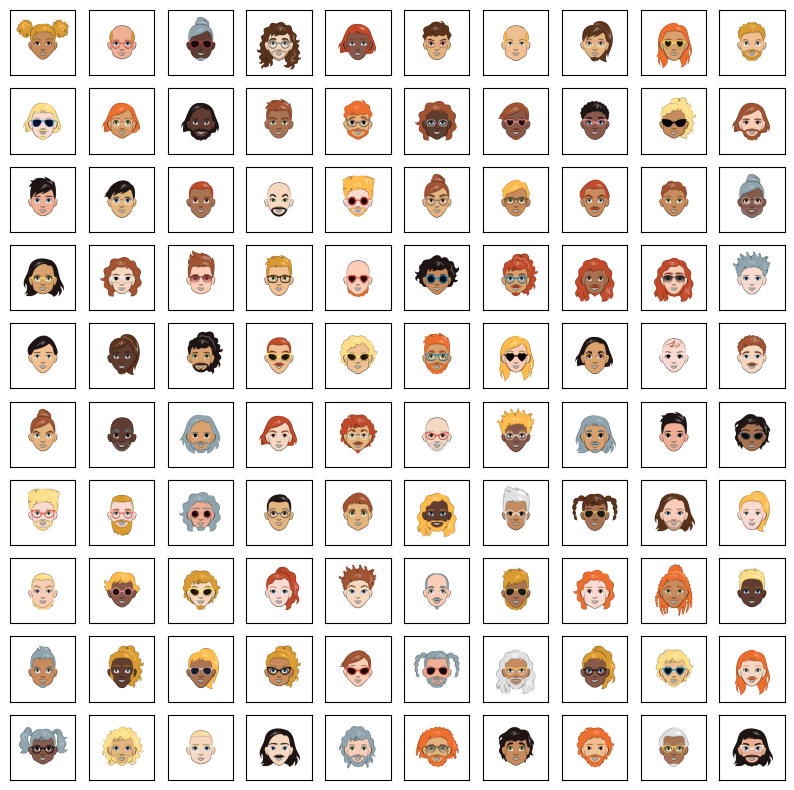

In [4]:
#посмотрим на данные
import pandas as pd
from PIL import Image

files_dir='cartoonset'
files_list_png = list(filter(lambda i: i[-3:] == 'png', os.listdir(files_dir)))
print(f'всего картинок: {len(files_list_png)}')
plt.figure(figsize=(10, 10))
num=1
for filename_png in files_list_png[:100]:
    filename_png_path = f'{files_dir}/{filename_png}'
    ax = plt.subplot(10, 10, num)
    image = Image.open(filename_png_path)
    if num == 1:
        print(f'размер: {image.size[0]}x{image.size[1]}')
    plt.imshow(image)
    ax.get_xaxis().set_visible(False)                             # Спрячем ось X
    ax.get_yaxis().set_visible(False)                              # Спрячем ось Y
    num += 1

for filename_png in files_list_png[:100]:
    filename_png_path = f'{files_dir}/{filename_png}'
    filename_csv_path = f'{filename_png_path[:-3]}csv'
    df = pd.read_csv(filename_csv_path)
    display(df.values)

In [5]:
import matplotlib.image as mpimg
import sys

#создание генератора обучающих данных
def train_data_gen(files_dir):
    files_list_png = list(filter(lambda i: i[-3:] == 'png', os.listdir(files_dir)))
    for filename_png in files_list_png[:100]:
        filename_png_path = f'{files_dir}/{filename_png}'
        np_image = (mpimg.imread(filename_png_path))
        yield np_image

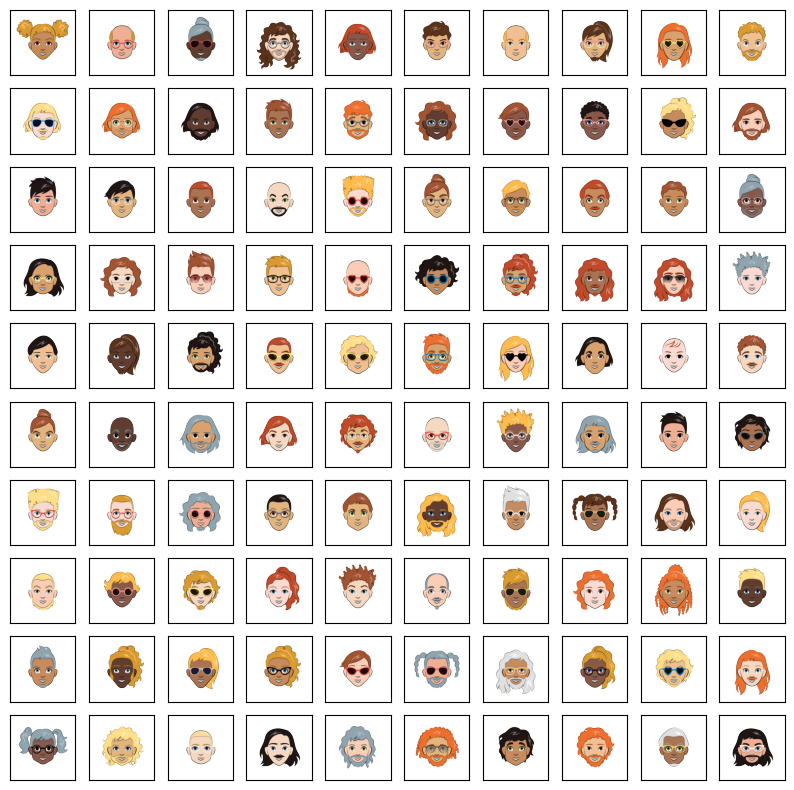

In [6]:
train_data = train_data_gen('cartoonset')
num=1
plt.figure(figsize=(10, 10))
for np_image in train_data:
    ax = plt.subplot(10, 10, num)
    plt.imshow(np_image)
    ax.get_xaxis().set_visible(False)                             # Спрячем ось X
    ax.get_yaxis().set_visible(False)
    num += 1
    if num > 100:
        train_data.close()